In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurazione grafici
sns.set_theme(style="whitegrid")
%matplotlib inline

## 1. Caricamento dei Dati

Utilizziamo il CSV del notebook precedente. data-1770028573715

In [2]:
# Caricamento dati da CSV (estratti dal DWH)
df = pd.read_csv("esercizio_bikesharing_sintetico.csv")

# Parsing data
df['data_completa'] = pd.to_datetime(df['data_completa'])

df.head()


,data_completa,mese,giorno_settimana,is_weekend,temp_c,pioggia_mm,evento,total_rentals,settimana_anno
0,2025-01-01,1,2,0,8.0,0.0,0,122,1
1,2025-01-02,1,3,0,4.7,0.0,0,94,1
2,2025-01-03,1,4,0,9.2,0.0,0,104,1
3,2025-01-04,1,5,1,9.7,0.0,0,116,1
4,2025-01-05,1,6,1,2.5,0.0,0,131,1


Ordiniamo per tempo

In [3]:
# Ordinamento temporale
df = df.sort_values("data_completa").reset_index(drop=True)


In [4]:
df['total_rentals'].describe()

count    365.000000
mean     121.652055
std       57.801403
min       10.000000
25%       79.000000
50%      118.000000
75%      169.000000
max      244.000000
Name: total_rentals, dtype: float64

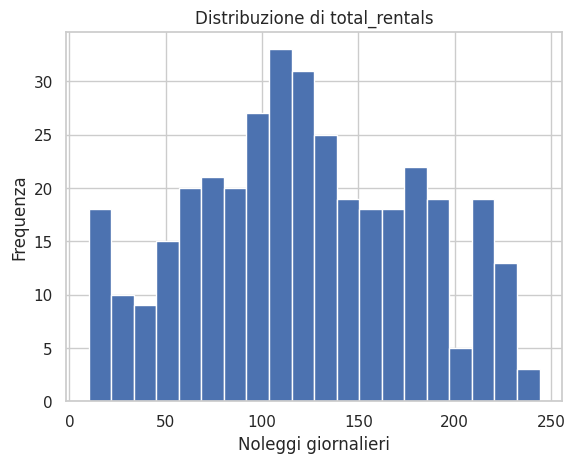

In [5]:
import matplotlib.pyplot as plt

plt.hist(df['total_rentals'], bins=20)
plt.xlabel('Noleggi giornalieri')
plt.ylabel('Frequenza')
plt.title('Distribuzione di total_rentals')
plt.show()

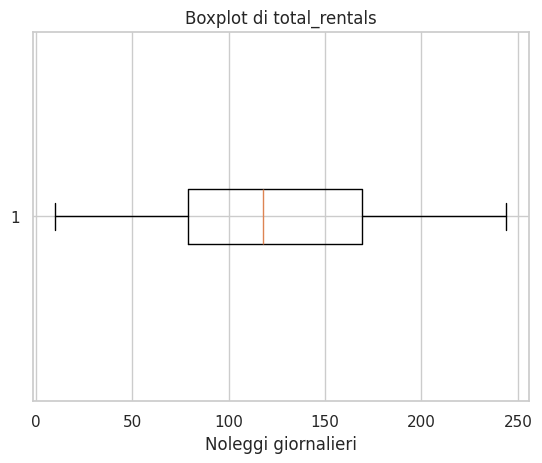

In [6]:
plt.boxplot(df['total_rentals'], vert=False)
plt.xlabel("Noleggi giornalieri")
plt.title("Boxplot di total_rentals")
plt.show()

Lag -diciamo al modello cosa è successo ieri

In [7]:
#per migliorare andamento della predizione, dobbiamo scalare le feature e le rendiamo adattabili al modello di ML 
from sklearn.preprocessing import StandardScaler 

scaler = StandardScaler()
df[['temp_c', 'pioggia_mm']] = scaler.fit_transform(
    df[['temp_c', 'pioggia_mm']]
)

In [8]:
# Feature: valore del giorno precedente
df['lag_1'] = df['total_rentals'].shift(1)

Media mobile (trend)

In [9]:
# Feature: media mobile ultimi 7 giorni
df['rolling_7'] = df['total_rentals'].rolling(window=7).mean()


Pulizia delle righe perchè alcune righe avranno valori nulli

In [10]:
# Rimuoviamo le righe iniziali con valori mancanti
df = df.dropna().reset_index(drop=True)


Stagionalità ciclica, rappresentazione del mese usando seno e coseno

In [11]:
# Trasformazione ciclica del mese
df['mese_sin'] = np.sin(2 * np.pi * df['mese'] / 12)
df['mese_cos'] = np.cos(2 * np.pi * df['mese'] / 12)
#Diamo un'equidistanza (ad esempio tra dicembre 12 e gennaio1 altrimenti ci sarebbe troppo gap)

Ridefiniamo le feature

In [12]:
features = [
    'giorno_settimana',
    'is_weekend',
    'lag_1',
    'rolling_7',
    'mese_sin',
    'mese_cos', 
    'temp_c', 
    'pioggia_mm',
    'evento'
]
target = 'total_rentals'

X = df[features]
y = df[target]

print(f"Shape di X: {X.shape}")
print(f"Shape di y: {y.shape}")

Shape di X: (359, 9)
Shape di y: (359,)


Split temporale non random

In [13]:
#definiamo train e test in maniera temporale 

split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]


Allenamento

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)


print("Intercetta:", model.intercept_)
print("Coefficienti:", dict(zip(features, model.coef_)))

Intercetta: 14.805881063669673
Coefficienti: {'giorno_settimana': np.float64(1.389071578553714), 'is_weekend': np.float64(-6.253238362565819), 'lag_1': np.float64(0.5715689531764427), 'rolling_7': np.float64(0.275936987902891), 'mese_sin': np.float64(-0.9931090649935086), 'mese_cos': np.float64(2.148675202439107), 'temp_c': np.float64(8.783236402320082), 'pioggia_mm': np.float64(-8.208080869465233), 'evento': np.float64(10.628176914679083)}


valutazione

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"MAE: (Errore medio assoluto): {mae:.2f}")
print(f"RMSE: (Radice Errore quadratico medio): {rmse:.2f}")

#introducendo informazione riusciamo a diminuire l'errore medio assoluto e la radice dell'errore quadratico medio

MAE: (Errore medio assoluto): 13.00
RMSE: (Radice Errore quadratico medio): 17.10


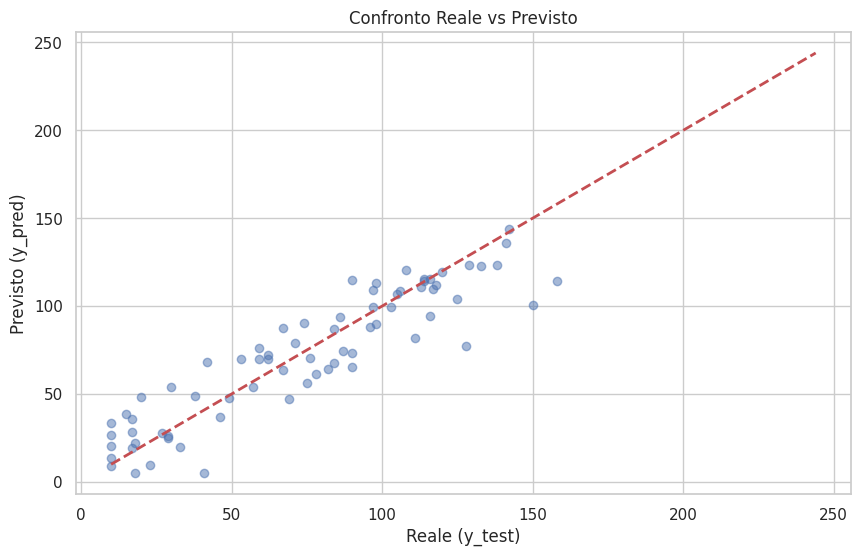

In [16]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Linea ideale
plt.xlabel('Reale (y_test)')
plt.ylabel('Previsto (y_pred)')
plt.title('Confronto Reale vs Previsto')
plt.show()